# Módulo 10 tarefa 2

Considere a mesma base de dados utilizada na tarefa 1 ```previsao_de_renda.csv```.

1) Com o que você viu em aula, faça uma análise das variáveis qualitativas (posse de imóvel e posse de veículo) para verificar se são boas preditoras de *renda*. Alguma delas parece discriminar *renda* de forma estatisticamente significante?

In [1]:
# Vamos carregar as bibliotecas necessárias para analisar os dados:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Agora, vamos carregar a nossa base de dados:
df = pd.read_csv("previsao_de_renda.csv")

In [3]:
# Vamos mostrar o DataFrame para visualização e verificação:
df.head(5)

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


### Vamos verificar se há uma boa correlação entre a variável "posse_de_imovel" e "renda". Primeiro vamos construir um DataFrame somente com as colunas de interesse:

In [4]:
# Construindo o DataFrame com as colunas "posse_de_imovel" e "renda":
df1 = df[["posse_de_imovel","renda"]]

# Mostrando o DataFrame para visualização e verificação:
df1.head(5)

,posse_de_imovel,renda
0,True,3369.24
1,True,6096.14
2,True,5658.98
3,False,7246.69
4,False,4017.37


In [5]:
# Vamos fazer uma cópia do DataFrame 'df1' para que os dados originais sejam mantidos:
df2 = df1.copy()

In [6]:
# Vamos trocar as variáveis booleanas de nosso DataFrame para inteiras pelo método mapping:
df2["posse_de_imovel"] = df2["posse_de_imovel"].map({True : 1, False: 0})

# Mostrando o gráfico novamente para visualização e verificação:
df2.head(5)

,posse_de_imovel,renda
0,1,3369.24
1,1,6096.14
2,1,5658.98
3,0,7246.69
4,0,4017.37


### Como "posse_de_imóvel" tem somente dois tipos de variáveis, vamos construir um gráfico de barras que irá trazer a média da renda das pessoas que possuem imóvel e a média daquelas que não possuem. Com isso, poderemos perceber se há uma relação entre estas duas variáveis.

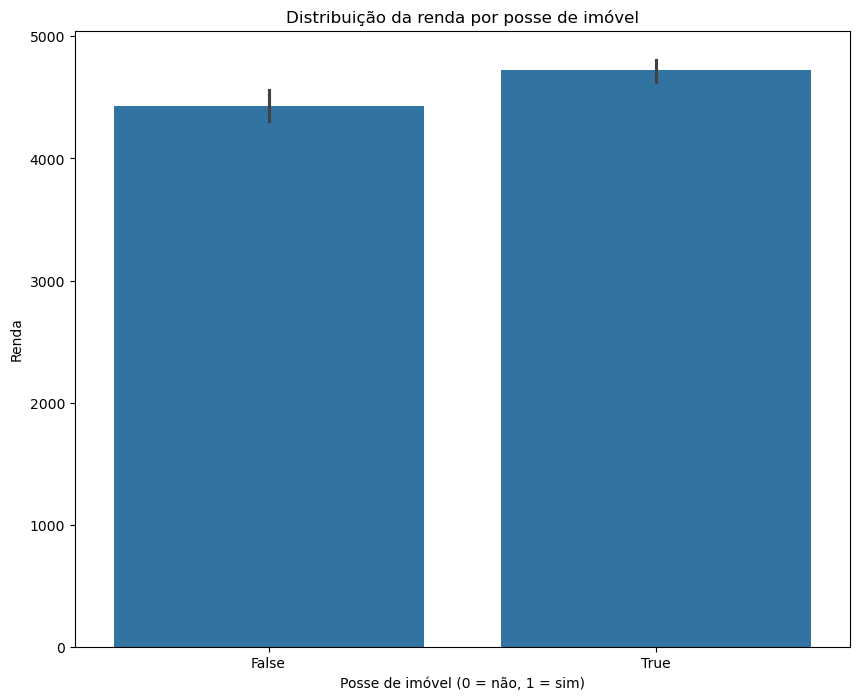

In [7]:
plt.figure( figsize = (10, 8) )
sns.barplot(x ='posse_de_imovel', 
            y='renda', 
            data = df1, 
            estimator = 'mean', 
            errorbar = ('ci', 95))
plt.title("Distribuição da renda por posse de imóvel")
plt.xlabel("Posse de imóvel (0 = não, 1 = sim)")
plt.ylabel("Renda")
plt.show()

### Podemos perceber que a média de renda dos clientes que possuem imóvel é ligeiramente maior do que aqueles que não possuem. 
### Vamos fazer a mesma análise agora com aqueles clientes que possuem veículo e verificar se há esta diferença também.

In [8]:
# Construindo o DataFrame com as colunas "posse_de_imovel" e "renda":
df3 = df[["posse_de_veiculo","renda"]]

# Mostrando o DataFrame para visualização e verificação:
df3.head(5)

,posse_de_veiculo,renda
0,False,3369.24
1,True,6096.14
2,True,5658.98
3,True,7246.69
4,False,4017.37


In [9]:
# Vamos fazer uma cópia do DataFrame 'df3' para que os dados originais sejam mantidos:
df4 = df3.copy()

In [11]:
# Vamos trocar as variáveis booleanas de nosso DataFrame para inteiras pelo método mapping:
df4["posse_de_veiculo"] = df4["posse_de_veiculo"].map({True : 1, False: 0})

# Mostrando o gráfico novamente para visualização e verificação:
df4.head(5)

,posse_de_veiculo,renda
0,0,3369.24
1,1,6096.14
2,1,5658.98
3,1,7246.69
4,0,4017.37


### Como "posse_de_imóvel" tem somente dois tipos de variáveis, vamos construir um gráfico de barras que irá trazer a média da renda das pessoas que possuem imóvel e a média daquelas que não possuem. Com isso, poderemos perceber se há uma relação entre estas duas variáveis.

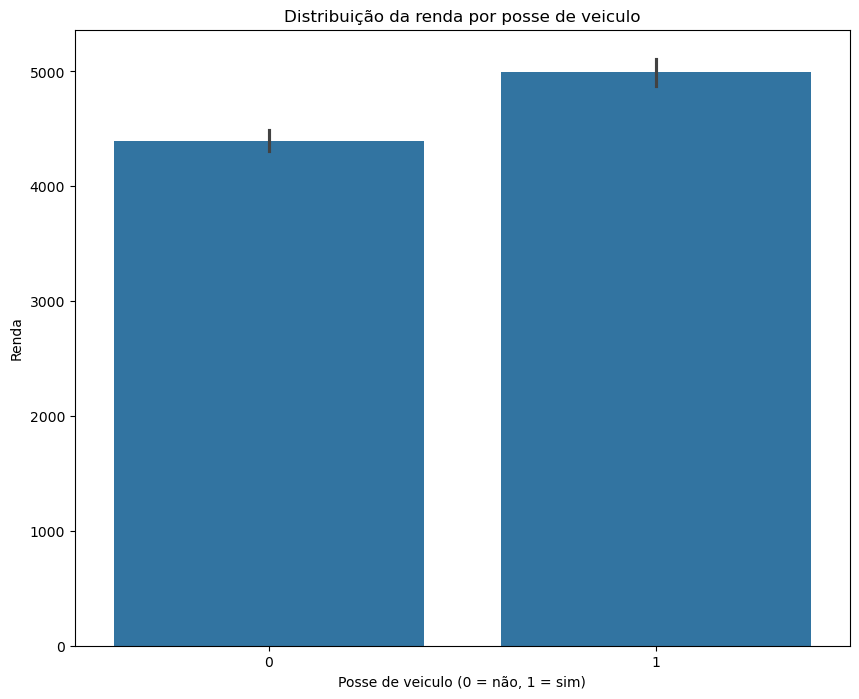

In [12]:
plt.figure( figsize = (10, 8) )
sns.barplot(x ='posse_de_veiculo', 
            y='renda', 
            data = df4, 
            estimator = 'mean', 
            errorbar = ('ci', 95))
plt.title("Distribuição da renda por posse de veiculo")
plt.xlabel("Posse de veiculo (0 = não, 1 = sim)")
plt.ylabel("Renda")
plt.show()

### Podemos perceber que a posse de veículo é uma característica mais determinante para que a renda do cliente seja maior do que a posse de um imóvel.
### Vamos fazer uma análise estatística para saber qual das duas têm maior influência na renda do cliente. Para isto, vamos criar um DataFrame com as colunas 'posse_de_imovel', 'posse_de_veiculo' e 'renda' para que possamos criar um gráfico que apresenta a relação entre a posse de imóveis ou de veículos e a renda do cliente.
### Vamos selecionar do DataFrame somente aqueles clientes que possuem imóveis e que possuem veículos, além da renda destas pessoas. Vamos calcular a média de renda para cada uma das categorias (donos de imóveis e donos de veículos) e, pela análise do intervalo de confiança, argumentar se a renda é estatisticamente discriminante para uma delas.

In [13]:
# Para isto, construímos o DataFrame com as três colunas necessárias para nossa análise:
df5 = df[['posse_de_imovel','posse_de_veiculo','renda']]

# Mostramos o DataFrame para visualização e verificação:
df5.head(5)

,posse_de_imovel,posse_de_veiculo,renda
0,True,False,3369.24
1,True,True,6096.14
2,True,True,5658.98
3,False,True,7246.69
4,False,False,4017.37


In [16]:
# Vamos selecionar somente as linhas em que aparecem os clientes que possuem imóvel ou veículo, criando um novo DataFrame:
df5_select = df5.loc[(df5['posse_de_imovel'] == True) | (df5['posse_de_veiculo'] == True),['posse_de_veiculo','posse_de_imovel','renda']]

# Mostrando o DataFrame para visualização e verificação:
df5_select.head(5)

,posse_de_veiculo,posse_de_imovel,renda
0,False,True,3369.24
1,True,True,6096.14
2,True,True,5658.98
3,True,False,7246.69
5,False,True,5483.58


In [17]:
# Vamos reorganizar o DataFrame:
df5_melt = df5.melt( id_vars = "renda",
                     value_vars = ["posse_de_imovel","posse_de_veiculo"],
                     var_name = "tipo_posse",
                     value_name = "possui"
                   )

# Mostramos o DataFrame para visualização e verificação:
df5_melt.head(5)

,renda,tipo_posse,possui
0,3369.24,posse_de_imovel,True
1,6096.14,posse_de_imovel,True
2,5658.98,posse_de_imovel,True
3,7246.69,posse_de_imovel,False
4,4017.37,posse_de_imovel,False


In [19]:
# Colocando rótulos amigáveis na coluna "tipo_posse"
df5_melt['tipo_posse'] = df5_melt['tipo_posse'].replace({'posse_de_imovel':'Imóvel', 'posse_de_veiculo':'Veículo'})

In [21]:
# Aplicando a função map para a coluna 'possui' para que se mude 'True' para 'Possui' e 'False' para 'Não possui':
df5_melt['possui'] = df5_melt['possui'].map({True : 'Possui', False : 'Não possui'})

In [22]:
# Vamos mostrar o DataFrame para visualização e verificação:
df5_melt.head(5)

,renda,tipo_posse,possui
0,3369.24,Imóvel,Possui
1,6096.14,Imóvel,Possui
2,5658.98,Imóvel,Possui
3,7246.69,Imóvel,Não possui
4,4017.37,Imóvel,Não possui


In [23]:
# Para que a ordem das categorias no eixo x seja "Imóvel" e "Veículo", vamos determiná-la na linha de código abaixo:
ordem_x = ['Imóvel','Veículo']

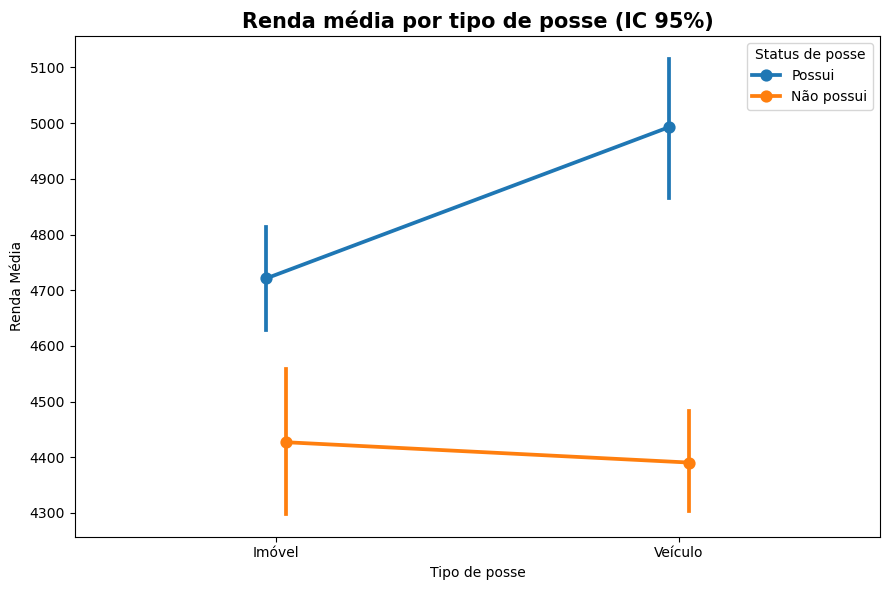

In [25]:
# As linhas de código abaixo mostram a construção de nosso gráfico:
plt.figure( figsize = (9,6) )
ax = sns.pointplot( data = df5_melt,
                    x = 'tipo_posse',
                    y = 'renda',
                    hue = 'possui',
                    dodge = True,
                    errorbar = ( 'ci', 95 ),
                    order = ordem_x
                  )

# Abaixo determinamos os rótulos do gráfico para ser mais informativo:
ax.set_title('Renda média por tipo de posse (IC 95%)', fontsize = 15, fontweight = 'bold')
ax.set_xlabel('Tipo de posse')
ax.set_ylabel('Renda Média')
ax.legend(title = 'Status de posse', loc = 'best')

# As linhas que servem para mostrar o gráfico são:
plt.tight_layout()
plt.show()

### A análise começa comparando as rendas médias entre os clientes que não possuem imóvel e aqueles que não possuem veículo. Observa-se que os intervalos de confiança são amplamente sobrepostos, o que sugere ausência de diferença estatisticamente relevante entre esses grupos. Assim, a renda média dos clientes sem bens não parece ser afetada pelo tipo de posse.

### Já na comparação entre clientes que possuem imóvel e os que possuem veículo, nota-se que os intervalos de confiança não se sobrepõem de forma significativa. Isso indica uma diferença estatisticamente relevante entre as médias, sendo que os clientes com veículo apresentam renda média mais alta do que os com imóvel.

### Portanto, a posse de veículo parece discriminar a renda de forma estatisticamente significativa, mostrando maior poder de distinção em relação à posse de imóvel.